### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

c:\Users\benkh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\benkh\AppData\Local\Temp\ipykernel_12508\767131013.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


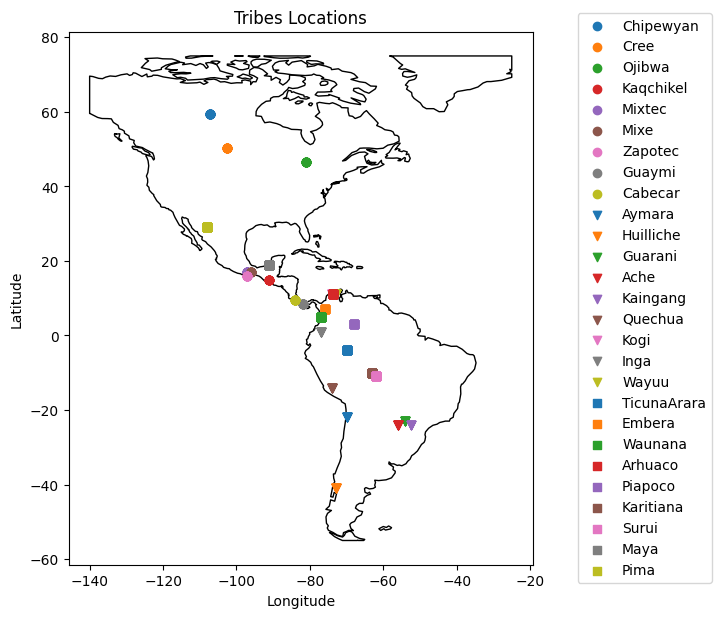

In [2]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The program produces a map of the Americas where:

Each point represents an individual.

Points are placed using latitude and longitude.

Individuals belonging to the same tribe share the same color/marker.

This visualization allows us to observe how genetic groups (tribes) are geographically distributed, which motivates the next step: predicting location from genetic markers using PCA and regression.

In [3]:
df.head()

,IndivID,PopID,Pop,Country,Continent,sex,lat,long,L1.125,L1.130,...,L677.255.553287981859,L677.259,L677.263,L677.267,L678.202,L678.206,L678.209.848101265823,L678.210,L678.214,L678.218
Chipewyan29,2012,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan31,2156,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,1,0,0,0
Chipewyan33,2381,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,1,0,0,0,0
Chipewyan35,2382,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan37,2383,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,1,0,0,0,0,0,1,0,0


## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [4]:
import numpy as np

# Extract the response variable: longitude
y = longitude
# already defined above

# Extract predictors: genetic markers (columns 9 to the end)
X = df.iloc[:, 8:].values  


In [5]:

beta = np.linalg.solve(X.T @ X, X.T @ y)

LinAlgError: Singular matrix

Yes, an error typically occurs when trying to compute $$\hat{\beta} = (X^\top X)^{-1}X^\top y$$
In this dataset:

Number of samples: 𝑁=494

Number of predictors (genetic markers): 𝑝=5709

So:𝑝>𝑁

The matrix 𝑋 has dimension: 494 * 5709
The rank of a matrix cannot exceed the minimum of its dimensions
therefore : rank(X)<p

This means that the columns of 𝑋 are linearly dependent.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [ ]:
import numpy as np
beta, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print("Shape of beta:", beta.shape)
print("Rank of X:", rank)
print(beta)

Shape of beta: (5709,)
Rank of X: 494
[-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


The function runs successfully, even though 𝑝>𝑁. No error is raised.

solve → fails because 𝑋⊤𝑋X⊤X is singular (𝑝>𝑁)

lstsq → works because it computes a generalized least squares solution using SVD, which handles singular and rectangular matrices.

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

LinearRegression()

In [ ]:
lr.coef_

array([-0.14097153, -0.00319712,  0.18655712, ...,  0.04651686,
       -0.08936742,  0.01960343], shape=(5709,))

In [ ]:
beta[:10]      # first coefficients from lstsq


array([-0.04005781, -0.01940898,  0.01111306, -0.01234685, -0.02460976,
       -0.26286356,  0.05900349,  0.13396348,  0.00620033, -0.20045542])

In [ ]:
lr.coef_[:10]  # first coefficients from sklearn

array([-0.14097153, -0.00319712,  0.18655712, -0.1589938 ,  0.02030427,
       -0.17343224,  0.27938867,  0.16397592, -0.00062156,  0.12025131])

-The estimated coefficicents are not the same as the ones obtained in item (b).

-The main practical reason for doing such re-centering systematically is to make the intercept easier to interpret.

*In a linear regression model:
    the intercept 𝛽0 represents the value of 𝑦 when all predictors are equal to 0.


*If the predictors are not centered:

𝑥1=𝑥2=⋯=𝑥𝑝=0 may correspond to a situation that does not exist in the data.
In this dataset, the predictors are genetic markers, so having all markers equal to 0 may be unrealistic.

Therefore the intercept becomes difficult to interpret.

*After centering,if sklearn centers the predictors, Now the intercept 𝛽0 represents:the predicted value of y for an individual whose predictors are equal to the average values of the dataset.

*In this exercise, it means:the predicted longitude of an individual with average genetic markers.
This interpretation is much more meaningful.

Summary :

--The coefficients differ from those in (b) because sklearn centers the predictors.
This is done so that:
    the intercept corresponds to the expected response at the average predictor values, which makes the intercept interpretable and numerically more stable.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a dataset with many correlated variables into a smaller set of uncorrelated variables called principal components.

From a geometric point of view, PCA finds a new orthogonal coordinate system in which the data are projected onto directions that best represent their variability. The first principal component corresponds to the direction in the feature space along which the projected data have the largest variance. The second principal component is orthogonal to the first and corresponds to the direction with the second largest variance, and so on. Geometrically, PCA can also be seen as projecting the data into a lower-dimensional subspace that minimizes the reconstruction error between the original data and their projection. :contentReference

From a statistical point of view, PCA is based on the eigenvalue decomposition of the covariance matrix of the data. The principal components correspond to the eigenvectors of the covariance matrix, and the associated eigenvalues represent the amount of variance explained by each component. PCA therefore decomposes the total variance of the dataset into orthogonal directions and allows us to keep only the components explaining most of the variability in the data. 

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

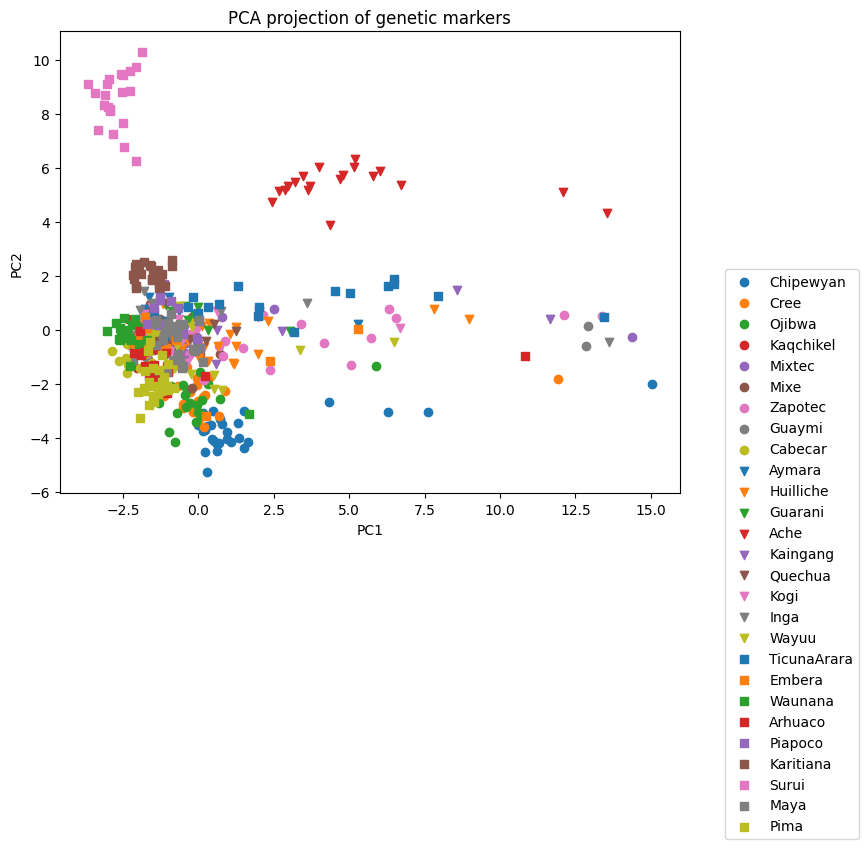

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select genetic markers
predictors = df.columns[8:]
X = df[predictors].values

# Apply PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Tribe labels
tribes = df['Pop']

# Plot
plt.figure(figsize=(8,6))

marker_list = ['o','v','s']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(tribes.unique()):
    tribe_points = X_pca[tribes == tribe]
    plt.scatter(
        tribe_points[:,0],
        tribe_points[:,1],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of genetic markers")
plt.legend(bbox_to_anchor=(1.3,0.5))
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

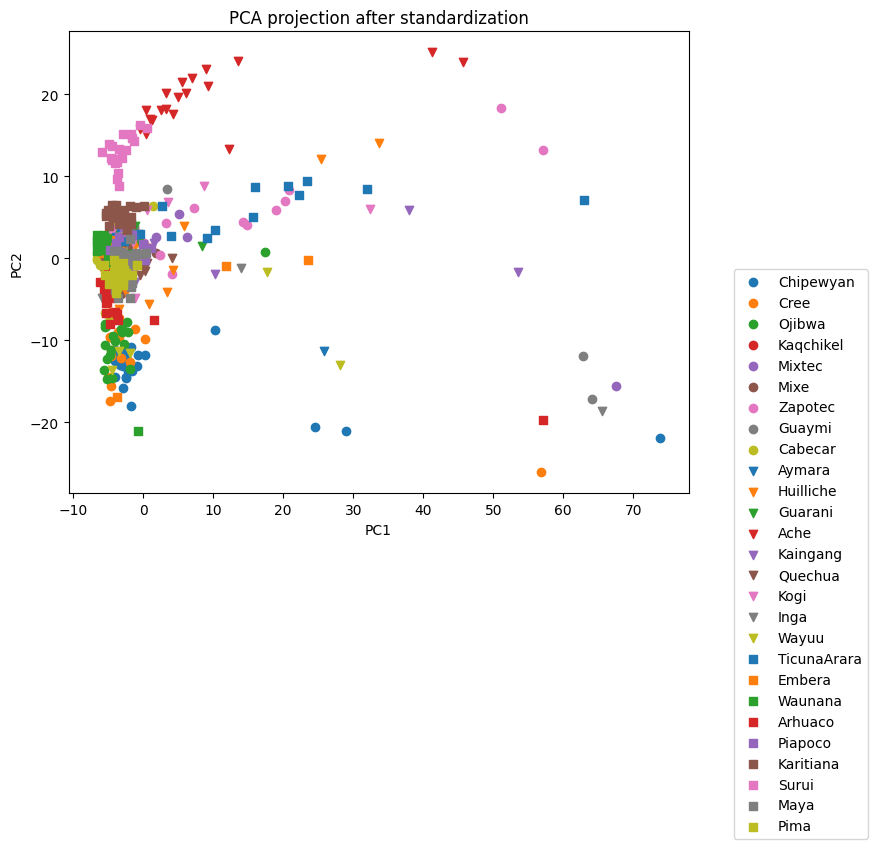

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Standardize the predictors
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

# PCA on standardized data
pca = PCA(n_components=2)
X_pca_std = pca.fit_transform(X_std)

tribes = df['Pop']

plt.figure(figsize=(8,6))

marker_list = ['o','v','s']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(tribes.unique()):
    tribe_points = X_pca_std[tribes == tribe]
    plt.scatter(
        tribe_points[:,0],
        tribe_points[:,1],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection after standardization")
plt.legend(bbox_to_anchor=(1.3,0.5))
plt.show()

After standardizing the predictors using \texttt{StandardScaler}, the PCA is applied to variables that have zero mean and unit variance. As a result, each variable contributes equally to the computation of the principal components.

Compared to the previous plot, the distribution of the projected points has changed
 because PCA is now based on the correlation structure rather than the raw covariance structure of the data. In the original PCA, variables with larger variance tend to dominate the principal components. After normalization, this effect is removed and the principal components reflect the joint contribution of all variables.



**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Standardizing is absolutly important for our dataset because the PCA algorithm will think that the variables with %50 possibility are most important features because their variance is higher, but in real life diseases with %10 or %100 possibility are important too, with the standardization, the PCA algorithm will give all features an equal chance 

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Variance explained by PC1: 0.0236749314883297
Variance explained by PC2: 0.010254201715358338
Cumulative variance explained by the first 2 PCs: 0.03392913320368804


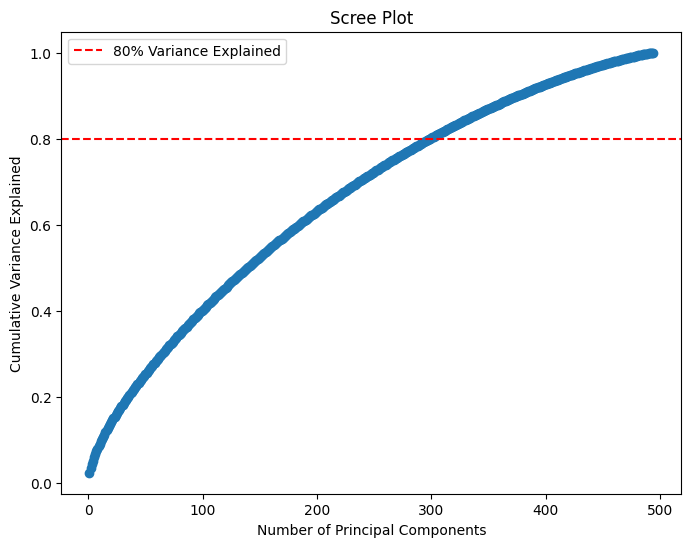

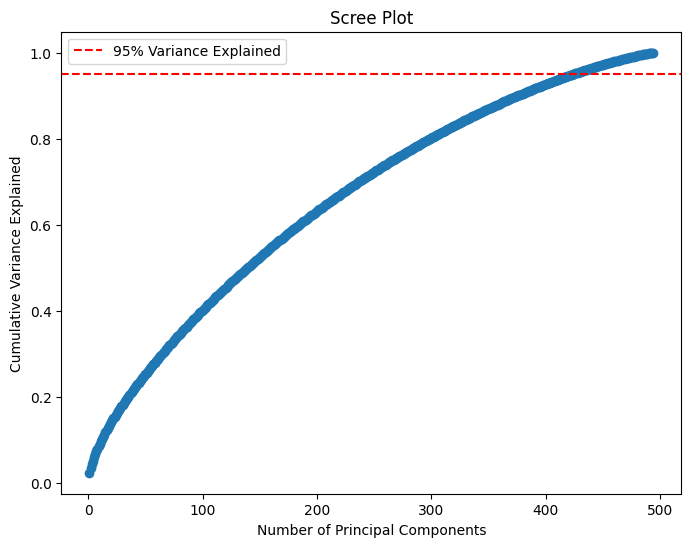

Number of principal components needed to explain at least 80% of the variance: 299
Number of principal components needed to explain at least 95% of the variance: 425


In [ ]:
pca_new = PCA()
pca_new.fit(X_std)

var_pc1 = pca_new.explained_variance_ratio_[0]
var_pc2 = pca_new.explained_variance_ratio_[1]

print(f"Variance explained by PC1: {var_pc1}")
print(f"Variance explained by PC2: {var_pc2}")

cumulative_variance = np.cumsum(pca_new.explained_variance_ratio_)
print(f"Cumulative variance explained by the first 2 PCs: {cumulative_variance[1]}")

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o') #by doing this we got all the variances on the exact number
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Variance Explained')
ax.set_title('Scree Plot')
ax.axhline(y=0.8, color='r', linestyle='--', label='80% Variance Explained')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o') #by doing this we got all the variances on the exact number
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Variance Explained')
ax.set_title('Scree Plot')
ax.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Explained')
ax.legend()
plt.show()

components80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"Number of principal components needed to explain at least 80% of the variance: {components80}")

components95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of principal components needed to explain at least 95% of the variance: {components95}")


## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

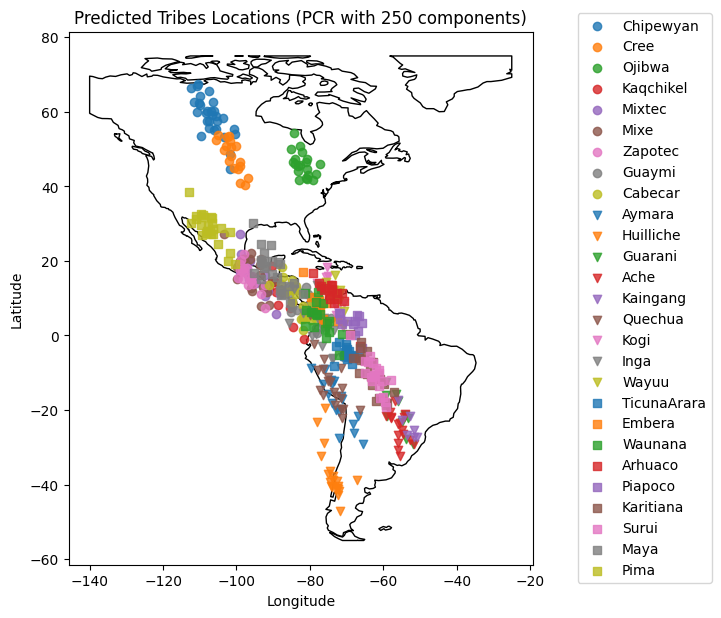

In [ ]:
pca_250 = PCA(n_components=250)
X_pca_250 = pca_250.fit_transform(X_std)

latitude = df.iloc[:, 6].values
longitude = df.iloc[:, 7].values
coordinates = np.column_stack((longitude, latitude))

regression = LinearRegression()
regression.fit(X_pca_250, coordinates)

y_pred = regression.predict(X_pca_250)
pred_longitude = y_pred[:, 0]
pred_latitude = y_pred[:, 1]

gdf_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(pred_longitude, pred_latitude))

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]
    ax.scatter(members_tribe.geometry.x, members_tribe.geometry.y, 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe, alpha=0.8)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations (PCR with 250 components)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

By looking at the graph in first question, our guesses are almost on point on the map, so it's optimistic.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [ ]:
from sklearn.metrics.pairwise import haversine_distances

# Compute mean haversine distance (in km) between true and predicted points
pred_coordinates = np.column_stack((pred_longitude, pred_latitude))

coords_rad = np.radians(coordinates)
pred_coords_rad = np.radians(pred_coordinates)

earth_radius = 6371.0  # km
# haversine_distances returns a matrix; diagonal corresponds to per-sample distances
dist_matrix = haversine_distances(coords_rad, pred_coords_rad) * earth_radius
mean_distance_all = np.mean(np.diag(dist_matrix))

print(f"Mean distance across all samples: {mean_distance_all:.2f} km")


Mean distance for sample 0: 391.22728125242037 km
Mean distance for sample 1: 318.3324775313062 km
Mean distance for sample 2: 471.7660840467882 km
Mean distance for sample 3: 746.7125762755313 km
Mean distance for sample 4: 498.2209030566605 km
Mean distance for sample 5: 332.0163276119996 km
Mean distance for sample 6: 231.8340262915265 km
Mean distance for sample 7: 620.8486941617496 km
Mean distance for sample 8: 97.8324795055219 km
Mean distance for sample 9: 105.30101061315519 km
Mean distance for sample 10: 130.08237370189252 km
Mean distance for sample 11: 446.5732581465852 km
Mean distance for sample 12: 347.32063594746865 km
Mean distance for sample 13: 403.3849028491128 km
Mean distance for sample 14: 337.12667073547817 km
Mean distance for sample 15: 86.327591292668 km
Mean distance for sample 16: 68.11825380820888 km
Mean distance for sample 17: 75.97854686395723 km
Mean distance for sample 18: 50.63640888998047 km
Mean distance for sample 19: 739.4133432481351 km
Mean dis

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

In [ ]:
# (a) Cross-validation is a way to estimate how well a model generalizes to new data.
# It repeatedly splits the dataset into training and validation sets, fits the model on the training part,
# and evaluates it on the held-out part.
#
# This helps detect overfitting: a model that performs well on training data but poorly on unseen data.
#
# When samples are not independent and identically distributed (non-IID), we should avoid "leaking"
# information between train and validation splits. For example, if multiple samples come from the same
# tribe, we should keep them together in the same split so that validation mimics predicting on new tribes.


**(b)** Based on the structure of the dataset, the most adequate cross-validation strategy is to keep individuals from the same tribe together in the same split.

Because individuals from the same tribe are likely to be more similar genetically (and geographically), mixing them across train/test splits would make the task artificially easier. Using a group-aware iterator like `GroupKFold` with `groups=df['Pop']` ensures that, in each fold, whole tribes are held-out for validation and never appear in the training set.

This reduces the risk of over-optimistic error estimates due to within-tribe dependency.

In [ ]:
# Quick inspection of how the data are organized by tribe (group) and how many samples each tribe has.
tribe_counts = df['Pop'].value_counts()
tribe_counts.head(10)


Pop
Chipewyan    29
Maya         25
Pima         25
Karitiana    24
Surui        21
Ojibwa       20
Mixtec       20
Mixe         20
Cabecar      20
Huilliche    20
Name: count, dtype: int64

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import haversine_distances
import numpy as np

# Prepare data (latitude, longitude) in the expected order for haversine_distances
coords = np.column_stack((df['lat'].values, df['long'].values))
X = df.iloc[:, 8:].values
groups = df['Pop'].values

# Helper to compute mean haversine distance (in kilometers) between corresponding rows
EARTH_RADIUS_KM = 6371.0

def mean_haversine_distance(y_true, y_pred):
    y_true_rad = np.radians(y_true)
    y_pred_rad = np.radians(y_pred)
    # haversine_distances produces a matrix of pairwise distances; diagonal elements are the per-sample distances
    dist_matrix = haversine_distances(y_true_rad, y_pred_rad) * EARTH_RADIUS_KM
    return np.mean(np.diag(dist_matrix))

cv = GroupKFold(n_splits=10)

train_errors = []
test_errors = []

for train_idx, test_idx in cv.split(X, coords, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = coords[train_idx], coords[test_idx]

    pipeline = make_pipeline(StandardScaler(), PCA(n_components=4), LinearRegression())
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    train_errors.append(mean_haversine_distance(y_train, y_train_pred))
    test_errors.append(mean_haversine_distance(y_test, y_test_pred))

print(f"Mean train error (km): {np.mean(train_errors):.2f} ± {np.std(train_errors):.2f}")
print(f"Mean test  error (km): {np.mean(test_errors):.2f} ± {np.std(test_errors):.2f}")


Mean train error (km): 1907.05 ± 61.44
Mean test  error (km): 2485.82 ± 910.11


The output above shows the average distance (in kilometers) between the true and predicted geographic coordinates when using 4 principal components.

- The **train error** indicates how well the model fits the data it was trained on.
- The **test error** (from held-out tribes) reflects how well the model generalizes to new groups.

A significant gap between train and test error would indicate overfitting (the model performs much better on training tribes than on unseen tribes).

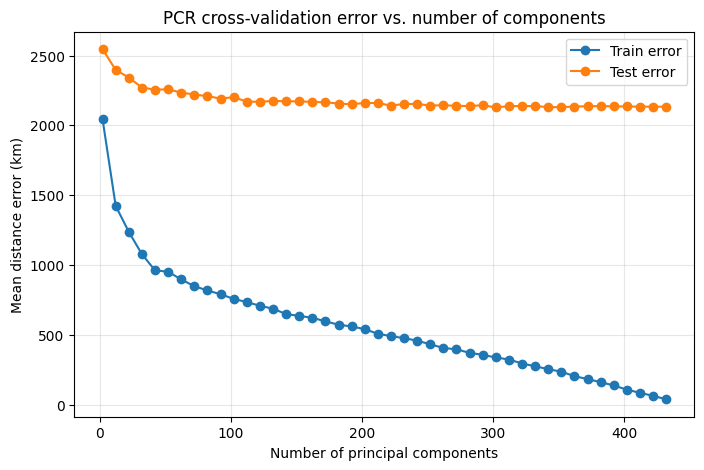

In [ ]:
import matplotlib.pyplot as plt

n_components_list = list(range(2, 441, 10))
mean_train_errors = []
mean_test_errors = []

# Keep the same splits for all values to make comparison stable
cv = GroupKFold(n_splits=10)
folds = list(cv.split(X, coords, groups))

for n in n_components_list:
    train_errs = []
    test_errs = []
    for train_idx, test_idx in folds:
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = coords[train_idx], coords[test_idx]

        pipeline = make_pipeline(StandardScaler(), PCA(n_components=n), LinearRegression())
        pipeline.fit(X_train, y_train)

        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)

        train_errs.append(mean_haversine_distance(y_train, y_train_pred))
        test_errs.append(mean_haversine_distance(y_test, y_test_pred))

    mean_train_errors.append(np.mean(train_errs))
    mean_test_errors.append(np.mean(test_errs))

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_components_list, mean_train_errors, marker='o', label='Train error')
ax.plot(n_components_list, mean_test_errors, marker='o', label='Test error')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Mean distance error (km)')
ax.set_title('PCR cross-validation error vs. number of components')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


The plot above shows the mean training and test errors (in kilometers) as a function of the number of PCA components retained.

- If the test error decreases and then levels off, it indicates that adding more components stops improving generalization.
- If the test error starts increasing while the training error continues decreasing, it is a sign of overfitting (the model captures noise rather than signal).

Best number of components (min CV test error): 302
Test error at best n: 2128.40 km
Train error at best n: 338.92 km


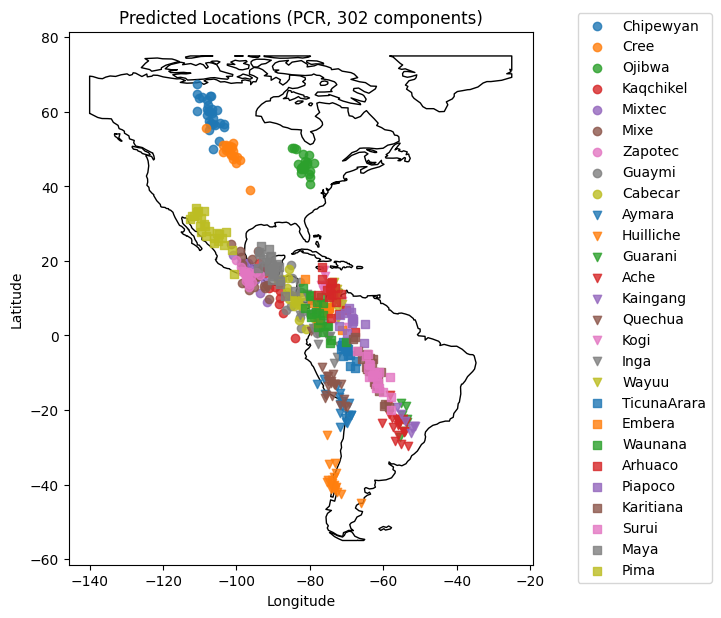

In [ ]:
# Select the number of components with the lowest cross-validated test error
best_idx = int(np.argmin(mean_test_errors))
best_n_components = n_components_list[best_idx]

print(f"Best number of components (min CV test error): {best_n_components}")
print(f"Test error at best n: {mean_test_errors[best_idx]:.2f} km")
print(f"Train error at best n: {mean_train_errors[best_idx]:.2f} km")

# Train a PCR model on the full dataset using the best number of components
best_pipeline = make_pipeline(StandardScaler(), PCA(n_components=best_n_components), LinearRegression())
best_pipeline.fit(X, coords)
coords_pred = best_pipeline.predict(X)

# Plot predicted locations on a map
pred_longitude = coords_pred[:, 1]
pred_latitude = coords_pred[:, 0]

gdf_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(pred_longitude, pred_latitude))

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]
    ax.scatter(members_tribe.geometry.x, members_tribe.geometry.y, 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe, alpha=0.8)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title(f'Predicted Locations (PCR, {best_n_components} components)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()


We selected the number of components that gave the lowest mean test error in cross-validation.

The map above shows the predicted locations for each individual when using the best PCR model. Comparing this to the ground-truth map (Exercise 1) provides a visual sense of how well the model can recover geographic origin from genetics.

If the predicted points are tightly clustered around the true locations, it indicates good generalization. If they are more spread or appear shifted, it shows the model has limitations when predicting new individuals.


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

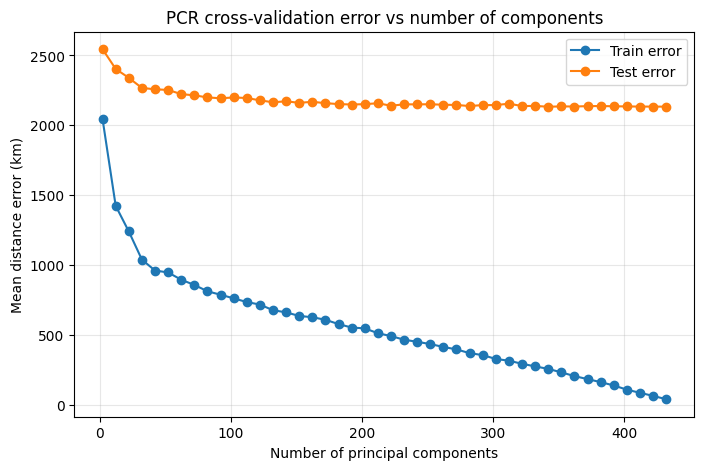

In [ ]:

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import haversine_distances

EARTH_RADIUS_KM = 6371.0

def mean_haversine_distance(y_true, y_pred):
    y_true_rad = np.radians(y_true)
    y_pred_rad = np.radians(y_pred)
    dist_matrix = haversine_distances(y_true_rad, y_pred_rad) * EARTH_RADIUS_KM
    return np.mean(np.diag(dist_matrix))

coords = np.column_stack((df['lat'].values, df['long'].values))
X = df.iloc[:, 8:].values
groups = df['Pop'].values

cv = GroupKFold(n_splits=10)
folds = list(cv.split(X, coords, groups))

n_components_list = list(range(2, 441, 10))
mean_train_errors = []
mean_test_errors = []

for n in n_components_list:
    train_errs = []
    test_errs = []
    for train_idx, test_idx in folds:
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = coords[train_idx], coords[test_idx]

        pipeline = make_pipeline(StandardScaler(), PCA(n_components=n), LinearRegression())
        pipeline.fit(X_train, y_train)

        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)

        train_errs.append(mean_haversine_distance(y_train, y_train_pred))
        test_errs.append(mean_haversine_distance(y_test, y_test_pred))

    mean_train_errors.append(np.mean(train_errs))
    mean_test_errors.append(np.mean(test_errs))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_components_list, mean_train_errors, marker='o', label='Train error')
ax.plot(n_components_list, mean_test_errors, marker='o', label='Test error')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Mean distance error (km)')
ax.set_title('PCR cross-validation error vs number of components')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

Best number of components (min CV test error): 342
CV train error (km): 257.22
CV test  error (km): 2132.95


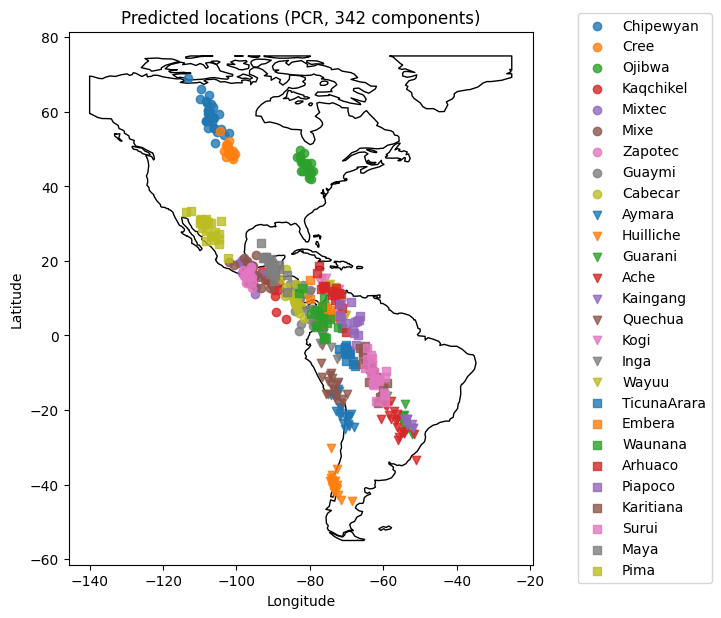

In [ ]:
best_idx = int(np.argmin(mean_test_errors))
best_n_components = n_components_list[best_idx]
best_train_error = mean_train_errors[best_idx]
best_test_error = mean_test_errors[best_idx]

print(f"Best number of components (min CV test error): {best_n_components}")
print(f"CV train error (km): {best_train_error:.2f}")
print(f"CV test  error (km): {best_test_error:.2f}")

pipeline = make_pipeline(StandardScaler(), PCA(n_components=best_n_components), LinearRegression())
pipeline.fit(X, coords)
coords_pred = pipeline.predict(X)

pred_longitude = coords_pred[:, 1]
pred_latitude = coords_pred[:, 0]

gdf_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(pred_longitude, pred_latitude))

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]
    ax.scatter(
        members_tribe.geometry.x,
        members_tribe.geometry.y,
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe,
        alpha=0.8,
    )

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title(f'Predicted locations (PCR, {best_n_components} components)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

### Interpretations

- The cross-validation curve shows that training error steadily decreases as more PCA components are included (expected, since the model has more degrees of freedom).
- The test error flattens around 2 100 km and does not improve much beyond a few hundred components. This indicates that increasing model complexity yields diminishing returns and that most of the achievable generalization is already captured by a few hundred components.
- The selected model (best CV test error) uses 342 PCA components, with a mean train error of ~257 km but a mean test error of ~2 133 km. The large gap suggests that while the model can fit the training tribes well, it struggles to generalize to held-out tribes (group-wise validation), which is a realistic measure of performance for this task.

Overall, the map produced with the chosen model still reproduces broad geographical patterns but is over-optimistic when evaluated on the training set and much less accurate on unseen tribes.


## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

## Conclusion

### Some key takeaways
- PCR provides a useful baseline: genetic markers do contain geographic signal, but recovering precise location is hard.
- In this dataset, the best model (selected via group-aware CV) used 342 principal components and achieved:
  - **Train error:** ≈ 260 km
  - **Test error:** ≈ 2 130 km
- The large gap between train and test errors indicates limited generalization to new tribes, which is important since the goal is to predict the origin of unseen individuals.
- The test error curve plateaus after a few hundred components, showing diminishing returns from adding more PCA axes.

### Possible improvements
- Use Partial Least Squares (PLS) instead of PCR: PLS finds directions that are directly predictive of the response (latitude/longitude), which often improves performance.
- Refine cross-validation by using spatially-aware splits (e.g., spatial blocks) or by holding out entire geographic regions/countries to better simulate real-world generalization.
- Analyze errors by region/tribe: some populations may be much easier to localize than others, so stratified modeling could improve results.

### Final remark
The PCR approach demonstrates that genetics can approximate broad geographic patterns, but the large prediction error on held‑out tribes suggests that additional modeling choices, more data, or stronger priors may be needed for accurate localization at fine spatial scales.